In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 576 events (all good), 0 – 0.801 s (baseline off), ~14.5 MB, data loaded,
 'Target': 96
 'NonTarget': 480>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 576 events (all good), 0 – 0.801 s (baseline off), ~14.5 MB, data loaded,
 'Target': 96
 'NonTarget': 480>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 576 events (all good), 0 – 0.801 s (baseline off), ~14.5 MB, data loaded,
 'Target': 96
 'NonTarget': 480>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

In [4]:
#%env PYTHONWARNINGS=error

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

hoda = HODA(
        rank=4,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='oas',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=True,
        verbose=True,
        random_state=42,
        delta=None,
        forward=True       


)


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

Backward HODA model rank=(4, 4):  59%|█████▉    | 38/64 [00:02<00:01, 15.49it/s]


,iteration,mode,update,shrinkage,rank,objective,F_tr,F_rt,log_loss
0,1,0,1.282419e+00,0.354511,4,0.000003,0.000035,0.001216,0.367063
1,1,1,1.524499e+00,1.000000,4,0.000001,0.000181,0.003446,0.242604
2,2,0,9.491520e-01,0.251246,4,0.000005,0.000231,0.002988,0.247858
3,2,1,1.141528e+00,1.000000,4,0.000001,0.000236,0.003016,0.243875
4,3,0,9.874074e-01,0.231033,4,0.000003,0.000261,0.003344,0.232640
...,...,...,...,...,...,...,...,...,...
73,37,1,1.822910e-08,1.000000,4,0.000001,0.000261,0.003533,0.218551
74,38,0,3.463843e-09,0.221848,4,0.000002,0.000261,0.003533,0.218551
75,38,1,1.169511e-08,1.000000,4,0.000001,0.000261,0.003533,0.218551
76,39,0,2.222939e-09,0.221848,4,0.000002,0.000261,0.003533,0.218551


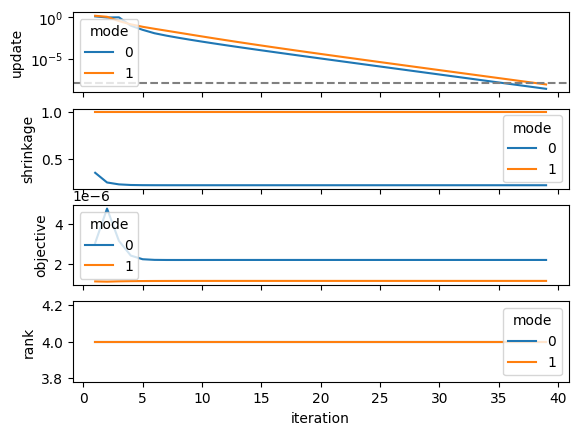

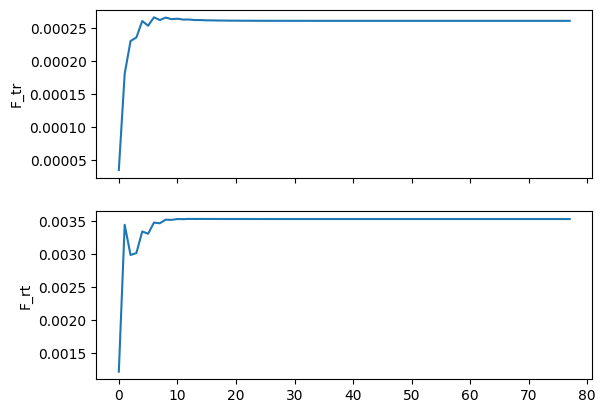

In [7]:
fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

In [8]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)

Forward model : 100%|██████████| 64/64 [00:00<00:00, 131.63it/s]


,iteration,mode,update,shrinkage,mse,nmse
0,0,0,inf,NaN,2.191405e-11,0.921724
1,0,1,inf,NaN,2.191405e-11,0.921724
2,1,0,1.250369,0.000121,1.944734e-11,0.817972
3,1,1,0.619791,0.002366,1.809812e-11,0.761222
4,2,0,0.264261,0.000122,1.808399e-11,0.760628
...,...,...,...,...,...,...
123,61,1,0.000142,0.002359,1.808350e-11,0.760608
124,62,0,0.000142,0.000122,1.808350e-11,0.760608
125,62,1,0.000142,0.002359,1.808350e-11,0.760608
126,63,0,0.000142,0.000122,1.808350e-11,0.760608


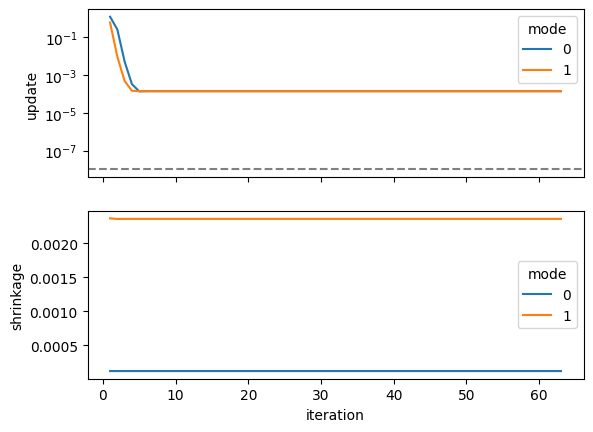

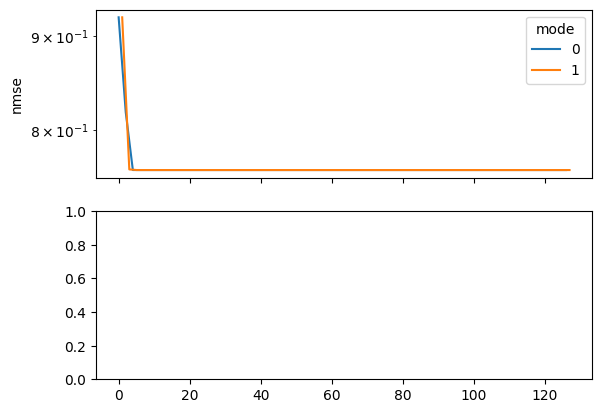

In [9]:

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='nmse', ax=axs[0], hue='mode')
    axs[0].set_yscale('log')


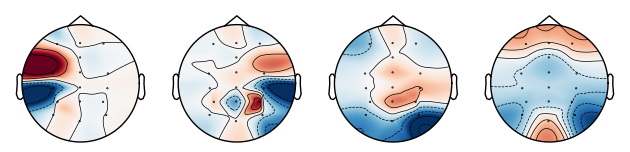

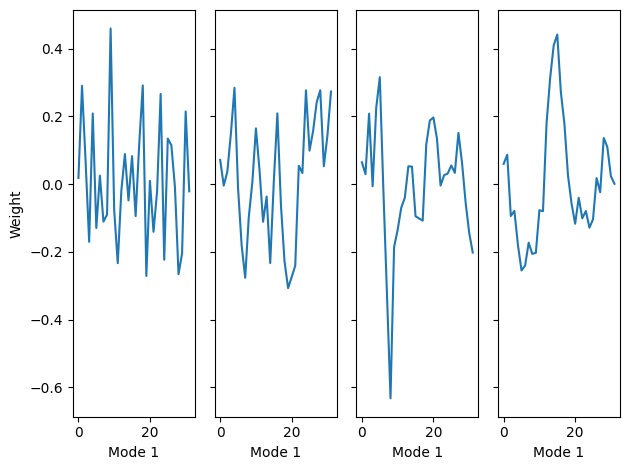

In [10]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');

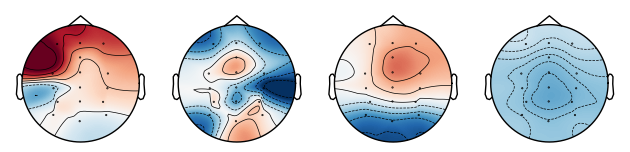

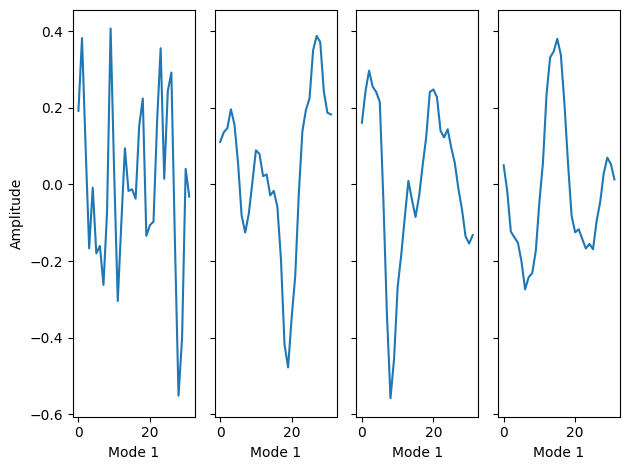

In [11]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

<Axes: >

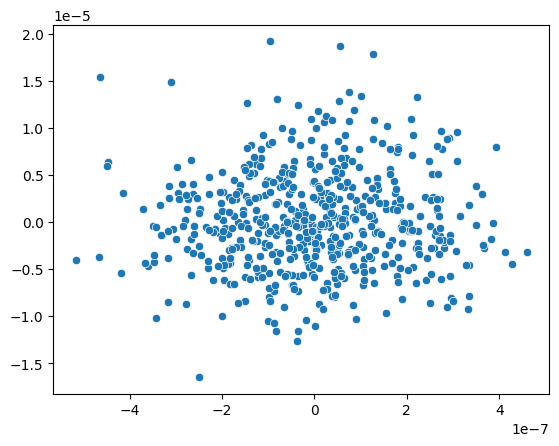

In [12]:
Xt = hoda.transform(X)
sns.scatterplot(x=tl.to_numpy(Xt[:,0,0]), y=tl.to_numpy(X[:,1,0]))